In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')

In [2]:
DATA_DIR = Path('../data/raw')
print(f"Data directory: {DATA_DIR.resolve()}\n")
print("Files found:")
for f in sorted(DATA_DIR.glob('*.csv')):
    size_mb = f.stat().st_size / 1024 / 1024
    print(f"  {f.name}: {size_mb:.1f} MB")

Data directory: C:\Data science\Project\Healthcare-Insurance-Claims-Analytics\data\raw

Files found:
  diagnosis_reference.csv: 0.0 MB
  dim_date.csv: 0.0 MB
  dim_patients.csv: 0.3 MB
  dim_policies.csv: 0.0 MB
  dim_providers.csv: 0.0 MB
  fact_claims.csv: 4.7 MB
  Test-1542969243754.csv: 0.0 MB
  Test_Beneficiarydata-1542969243754.csv: 5.1 MB
  Test_Inpatientdata-1542969243754.csv: 1.9 MB
  Test_Outpatientdata-1542969243754.csv: 17.9 MB
  Train-1542865627584.csv: 0.1 MB
  Train_Beneficiarydata-1542865627584.csv: 10.9 MB
  Train_Inpatientdata-1542865627584.csv: 8.2 MB
  Train_Outpatientdata-1542865627584.csv: 73.8 MB


In [3]:
def find_csv(prefix):
    """Find a CSV by prefix; tolerates Kaggle's timestamped filenames."""
    exact = DATA_DIR / f'{prefix}.csv'
    if exact.exists():
        return exact
    matches = sorted(DATA_DIR.glob(f'{prefix}-*.csv'))
    if matches:
        return matches[0]
    raise FileNotFoundError(f'No CSV found for prefix: {prefix}')

print("Loading Train.csv (provider-level with fraud labels)...")
train = pd.read_csv(find_csv('Train'))

print("Loading Train_Beneficiarydata.csv (patient demographics + chronic conditions)...")
beneficiary = pd.read_csv(find_csv('Train_Beneficiarydata'))

print("Loading Train_Inpatientdata.csv (hospital admission claims)...")
inpatient = pd.read_csv(find_csv('Train_Inpatientdata'))

print("Loading Train_Outpatientdata.csv (outpatient visit claims)...")
outpatient = pd.read_csv(find_csv('Train_Outpatientdata'))

print("\nAll loaded successfully.")

Loading Train.csv (provider-level with fraud labels)...
Loading Train_Beneficiarydata.csv (patient demographics + chronic conditions)...


Loading Train_Inpatientdata.csv (hospital admission claims)...


Loading Train_Outpatientdata.csv (outpatient visit claims)...



All loaded successfully.


In [4]:
print("Dataset shapes:")
print(f"  Train (providers):     {train.shape[0]:>8,} rows × {train.shape[1]} cols")
print(f"  Beneficiary (patients):{beneficiary.shape[0]:>8,} rows × {beneficiary.shape[1]} cols")
print(f"  Inpatient claims:      {inpatient.shape[0]:>8,} rows × {inpatient.shape[1]} cols")
print(f"  Outpatient claims:     {outpatient.shape[0]:>8,} rows × {outpatient.shape[1]} cols")
print(f"\n  TOTAL claims:          {len(inpatient) + len(outpatient):>8,}")

Dataset shapes:
  Train (providers):        5,410 rows × 2 cols
  Beneficiary (patients): 138,556 rows × 25 cols
  Inpatient claims:        40,474 rows × 30 cols
  Outpatient claims:      517,737 rows × 27 cols

  TOTAL claims:           558,211


In [5]:
print("Train.csv columns:", train.columns.tolist())
print("\nFraud label counts:")
print(train['PotentialFraud'].value_counts())
print("\nFraud label distribution (%):")
print((train['PotentialFraud'].value_counts(normalize=True) * 100).round(2))

Train.csv columns: ['Provider', 'PotentialFraud']

Fraud label counts:
PotentialFraud
No     4904
Yes     506
Name: count, dtype: int64

Fraud label distribution (%):
PotentialFraud
No     90.65
Yes     9.35
Name: proportion, dtype: float64


In [6]:
print("Beneficiary columns:")
print(beneficiary.columns.tolist())
print()
beneficiary.head()

Beneficiary columns:
['BeneID', 'DOB', 'DOD', 'Gender', 'Race', 'RenalDiseaseIndicator', 'State', 'County', 'NoOfMonths_PartACov', 'NoOfMonths_PartBCov', 'ChronicCond_Alzheimer', 'ChronicCond_Heartfailure', 'ChronicCond_KidneyDisease', 'ChronicCond_Cancer', 'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression', 'ChronicCond_Diabetes', 'ChronicCond_IschemicHeart', 'ChronicCond_Osteoporasis', 'ChronicCond_rheumatoidarthritis', 'ChronicCond_stroke', 'IPAnnualReimbursementAmt', 'IPAnnualDeductibleAmt', 'OPAnnualReimbursementAmt', 'OPAnnualDeductibleAmt']



,BeneID,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,ChronicCond_Alzheimer,ChronicCond_Heartfailure,ChronicCond_KidneyDisease,ChronicCond_Cancer,ChronicCond_ObstrPulmonary,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt
0,BENE11001,1943-01-01,NaN,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70
1,BENE11002,1936-09-01,NaN,2,1,0,39,280,12,12,2,2,2,2,2,2,2,2,2,2,2,0,0,30,50
2,BENE11003,1936-08-01,NaN,1,1,0,52,590,12,12,1,2,2,2,2,2,2,1,2,2,2,0,0,90,40
3,BENE11004,1922-07-01,NaN,1,1,0,39,270,12,12,1,1,2,2,2,2,1,1,1,1,2,0,0,1810,760
4,BENE11005,1935-09-01,NaN,1,1,0,24,680,12,12,2,2,2,2,1,2,1,2,2,2,2,0,0,1790,1200


In [7]:
chronic_cols = [c for c in beneficiary.columns if c.startswith('ChronicCond_')]
print(f"Number of chronic condition columns: {len(chronic_cols)}\n")

# IMPORTANT: Verify what the values mean in this dataset
# Don't assume 0/1 — check the actual values
print(f"Value counts for {chronic_cols[0]}:")
print(beneficiary[chronic_cols[0]].value_counts())
print("\nLook at the values above. Note which value means 'Yes' (has condition) vs 'No'.")
print("Common conventions: 1=Yes/2=No  OR  0=No/1=Yes  — verify before computing prevalence.")

Number of chronic condition columns: 11

Value counts for ChronicCond_Alzheimer:
ChronicCond_Alzheimer
2    92530
1    46026
Name: count, dtype: int64

Look at the values above. Note which value means 'Yes' (has condition) vs 'No'.
Common conventions: 1=Yes/2=No  OR  0=No/1=Yes  — verify before computing prevalence.


In [8]:
# Update YES_VALUE based on what you found in Cell 7
YES_VALUE = 1  # Change this if the encoding is different in this dataset

print(f"Prevalence of each chronic condition (assuming {YES_VALUE} = Yes):\n")
for col in chronic_cols:
    pct = (beneficiary[col] == YES_VALUE).mean() * 100
    name = col.replace('ChronicCond_', '')
    print(f"  {name:25s}: {pct:5.1f}%")

Prevalence of each chronic condition (assuming 1 = Yes):

  Alzheimer                :  33.2%
  Heartfailure             :  49.4%
  KidneyDisease            :  31.2%
  Cancer                   :  12.0%
  ObstrPulmonary           :  23.7%
  Depression               :  35.6%
  Diabetes                 :  60.2%
  IschemicHeart            :  67.6%
  Osteoporasis             :  27.5%
  rheumatoidarthritis      :  25.7%
  stroke                   :   7.9%


Inpatient claim amount summary (USD):
count     40474.00
mean      10087.88
std       10303.10
min           0.00
25%        4000.00
50%        7000.00
75%       12000.00
max      125000.00
Name: InscClaimAmtReimbursed, dtype: float64


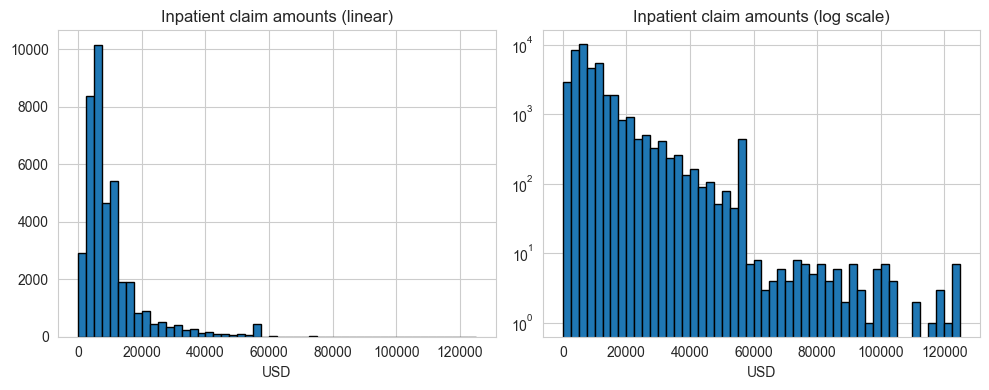

In [9]:
print("Inpatient claim amount summary (USD):")
print(inpatient['InscClaimAmtReimbursed'].describe().round(2))

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(inpatient['InscClaimAmtReimbursed'], bins=50, edgecolor='black')
plt.title('Inpatient claim amounts (linear)')
plt.xlabel('USD')

plt.subplot(1, 2, 2)
plt.hist(inpatient['InscClaimAmtReimbursed'], bins=50, edgecolor='black')
plt.yscale('log')
plt.title('Inpatient claim amounts (log scale)')
plt.xlabel('USD')
plt.tight_layout()
plt.show()

In [10]:
print("Outpatient claim amount summary (USD):")
print(outpatient['InscClaimAmtReimbursed'].describe().round(2))

Outpatient claim amount summary (USD):
count    517737.00
mean        286.33
std         694.03
min           0.00
25%          40.00
50%          80.00
75%         200.00
max      102500.00
Name: InscClaimAmtReimbursed, dtype: float64


In [11]:
def missing_summary(df, name):
    miss = df.isna().sum()
    miss = miss[miss > 0].sort_values(ascending=False)
    pct = (miss / len(df) * 100).round(2)
    summary = pd.DataFrame({'missing_count': miss, 'missing_pct': pct})
    print(f"=== {name} — top columns with missing data ===")
    print(summary.head(15))
    print()

missing_summary(beneficiary, 'Beneficiary')
missing_summary(inpatient, 'Inpatient')
missing_summary(outpatient, 'Outpatient')

=== Beneficiary — top columns with missing data ===
     missing_count  missing_pct
DOD         137135        98.97

=== Inpatient — top columns with missing data ===
                     missing_count  missing_pct
ClmProcedureCode_6           40474       100.00
ClmProcedureCode_5           40465        99.98
ClmProcedureCode_4           40358        99.71
ClmProcedureCode_3           39509        97.62
ClmDiagnosisCode_10          36547        90.30
OtherPhysician               35784        88.41
ClmProcedureCode_2           35020        86.52
ClmProcedureCode_1           17326        42.81
OperatingPhysician           16644        41.12
ClmDiagnosisCode_9           13497        33.35
ClmDiagnosisCode_8            9942        24.56
ClmDiagnosisCode_7            7258        17.93
ClmDiagnosisCode_6            4838        11.95
ClmDiagnosisCode_5            2894         7.15
ClmDiagnosisCode_4            1534         3.79



=== Outpatient — top columns with missing data ===
                       missing_count  missing_pct
ClmProcedureCode_6            517737       100.00
ClmProcedureCode_5            517737       100.00
ClmProcedureCode_4            517735       100.00
ClmProcedureCode_3            517733       100.00
ClmProcedureCode_2            517701        99.99
ClmProcedureCode_1            517575        99.97
ClmDiagnosisCode_10           516654        99.79
ClmDiagnosisCode_9            502899        97.13
ClmDiagnosisCode_8            494825        95.57
ClmDiagnosisCode_7            484776        93.63
ClmDiagnosisCode_6            468981        90.58
ClmDiagnosisCode_5            443393        85.64
OperatingPhysician            427120        82.50
ClmAdmitDiagnosisCode         412312        79.64
ClmDiagnosisCode_4            392141        75.74



In [12]:
# Each claim has a Provider ID. Each provider has a fraud label in Train.csv.
# Let's see how many claims belong to fraudulent vs non-fraudulent providers.

inp_with_fraud = inpatient.merge(train, on='Provider', how='left')
out_with_fraud = outpatient.merge(train, on='Provider', how='left')

print("Inpatient claims by provider fraud label:")
print(inp_with_fraud['PotentialFraud'].value_counts())
print(f"  Total $ claimed by fraud-flagged providers: "
      f"${inp_with_fraud[inp_with_fraud['PotentialFraud']=='Yes']['InscClaimAmtReimbursed'].sum():,.0f}")

print("\nOutpatient claims by provider fraud label:")
print(out_with_fraud['PotentialFraud'].value_counts())
print(f"  Total $ claimed by fraud-flagged providers: "
      f"${out_with_fraud[out_with_fraud['PotentialFraud']=='Yes']['InscClaimAmtReimbursed'].sum():,.0f}")

Inpatient claims by provider fraud label:
PotentialFraud
Yes    23402
No     17072
Name: count, dtype: int64
  Total $ claimed by fraud-flagged providers: $241,288,510

Outpatient claims by provider fraud label:
PotentialFraud
No     328343
Yes    189394
Name: count, dtype: int64


  Total $ claimed by fraud-flagged providers: $54,392,610


## 5 Things That Surprised Me About This Data

1. ...
2. ...
3. ...
4. ...
5. ...

(Look at fraud class imbalance, chronic condition prevalence, claim amount tails,
missing data patterns, fraud-flagged-provider claim concentration. Pick what genuinely
surprised you — interviewers love specific surprises far more than generic findings.)